Page Views Time Series Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/freeCodeCamp/boilerplate-page-view-time-series-visualizer/main/fcc-forum-pageviews.csv"
data = pd.read_csv(url, index_col='date', parse_dates=['date'])
data.head()


,value
date,
2016-05-09,1201
2016-05-10,2329
2016-05-11,1716
2016-05-12,10539
2016-05-13,6933


Data Cleaning : Filtering out top and bottom 2.5%

In [ ]:
data_cleaned = data[(data['value']>= data['value'].quantile(0.025)) &
                    (data['value']<= data['value'].quantile(0.975))]

line sketch function that employs the use of matplotlib for visualization ; this indicates wether my POI is growing or loosing traction overtime.

Text(0, 0.5, 'Page Views')

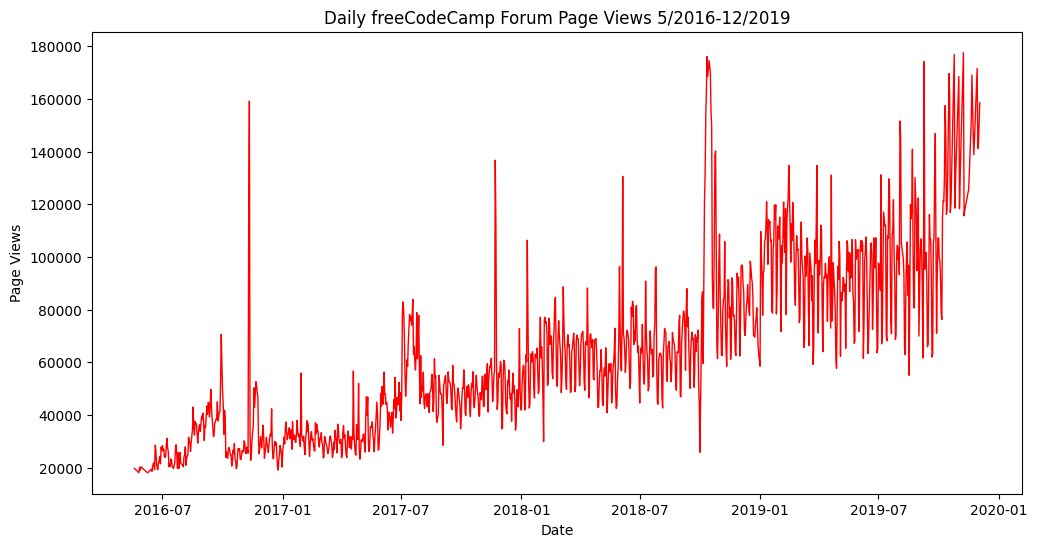

In [ ]:
fig, ax = plt.subplots(figsize = (12,6))
ax.plot(data_cleaned.index, data_cleaned['value'],color='red',linewidth=1 )
ax.set_title ('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
ax.set_xlabel('Date')
ax.set_ylabel('Page Views')


Analysing Seasonal Trends Through Use Of Grouped Barcharts

Text(0, 0.5, 'Average Page Views')

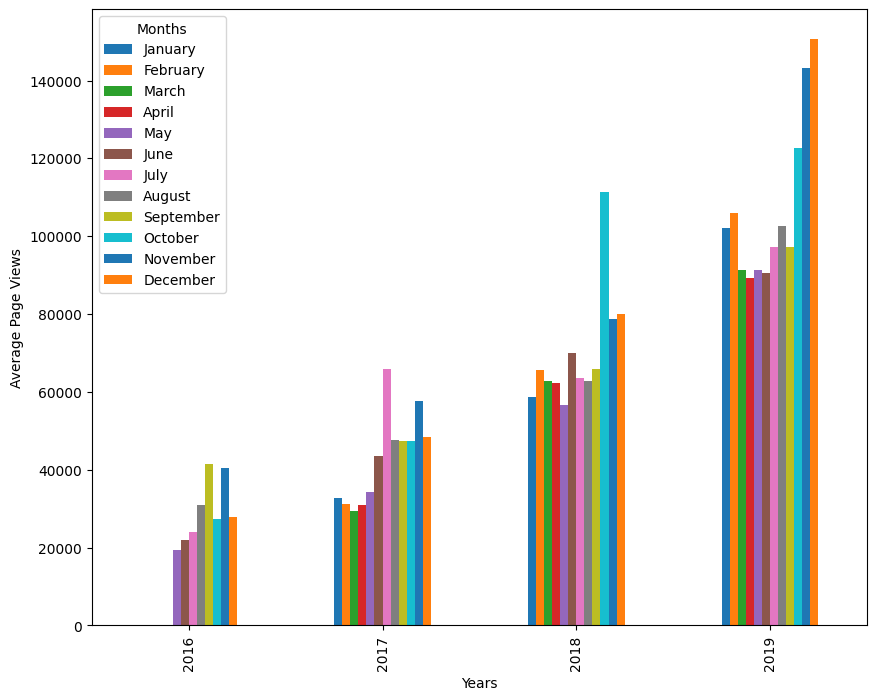

In [ ]:
data_bar = data_cleaned.copy()
data_bar['year']= data_bar.index.year
data_bar['month']= data_bar.index.strftime('%B')

data_pivot= data_bar.groupby(['year','month'])['value'].mean().unstack()
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
data_pivot = data_pivot[months_order]

fig = data_pivot.plot(kind='bar', figsize=(10,8)).get_figure()
plt.legend(title='Months')
plt.xlabel('Years')
plt.ylabel('Average Page Views')

Analysing Distribution and Variance Using Box Plot

Text(0, 0.5, 'Page Views')

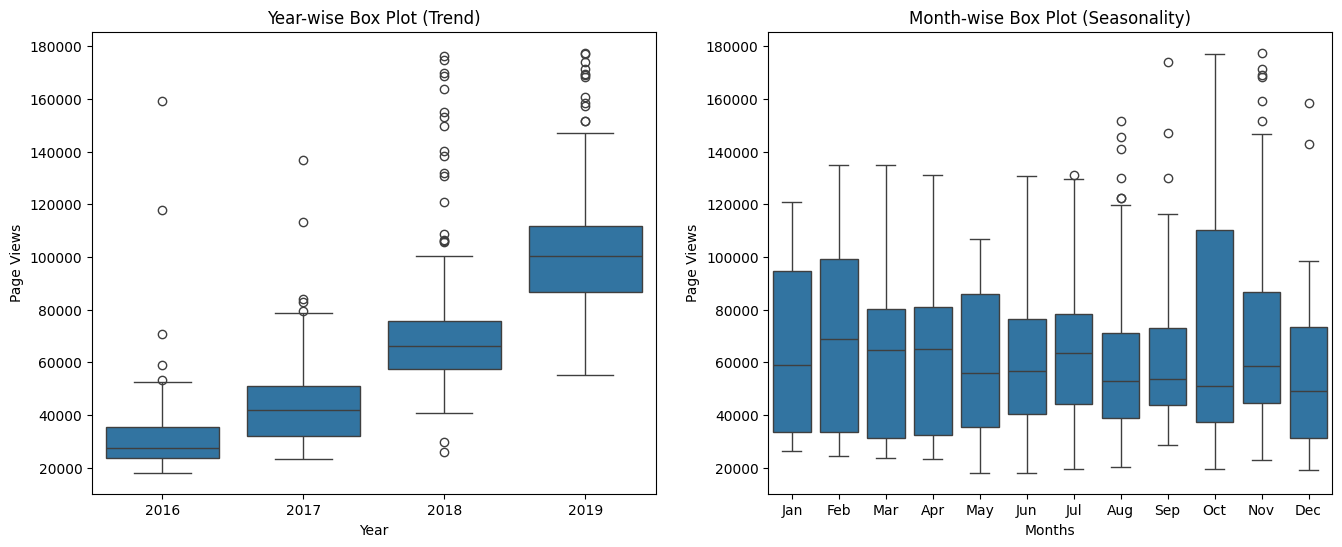

In [ ]:
data_box = data_cleaned.copy()
data_box.reset_index(inplace = True)
data_box['year'] = [d.year for d in data_box.date]
data_box['month'] = [d.strftime('%b') for d in data_box.date]

fig, axes = plt.subplots(1,2, figsize = (16,6))

sns.boxplot(x='year', y='value', data=data_box, ax=axes[0])
axes[0].set_title('Year-wise Box Plot (Trend)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Page Views')

short_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
sns.boxplot(x='month', y='value', data=data_box, ax=axes[1], order=short_months)
axes[1].set_title("Month-wise Box Plot (Seasonality)")
axes[1].set_xlabel('Months')
axes[1].set_ylabel('Page Views')